# Inventory Management Implementation Notebook

Start-to-finish implementation for inventory analytics on `ecommerce.db` with:
- ABC/XYZ segmentation
- Reorder Point (ROP) and EOQ recommendations
- Inventory-focused exploratory analysis
- Agent-ready recommendation outputs

## 1. Set Up Environment and Imports

In [14]:
import os
import sqlite3
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid')

print('Python modules loaded successfully')
print('pandas', pd.__version__)
print('numpy', np.__version__)

Python modules loaded successfully
pandas 2.3.3
numpy 1.26.4


## 2. Define Configuration and Constants

In [15]:
@dataclass
class InventoryConfig:
    db_path: str = os.getenv('DB_PATH', '/home/miko/magister/ecommerce.db')
    output_dir: str = 'artifacts/inventory_analysis'
    planning_horizon_days: int = 30
    lead_time_days: int = 7
    service_level: float = 0.95
    service_z: float = 1.645  # Approx z-score for 95% cycle service level
    demand_anchor_mode: str = 'last_nonzero'  # 'latest' or 'last_nonzero'

    # ABC class-based EOQ assumptions
    order_cost_by_abc: Dict[str, float] = None
    holding_cost_rate_by_abc: Dict[str, float] = None

    def __post_init__(self):
        if self.order_cost_by_abc is None:
            self.order_cost_by_abc = {'A': 70.0, 'B': 50.0, 'C': 35.0}
        if self.holding_cost_rate_by_abc is None:
            self.holding_cost_rate_by_abc = {'A': 0.30, 'B': 0.24, 'C': 0.18}

cfg = InventoryConfig()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
cfg

InventoryConfig(db_path='/home/miko/magister/ecommerce.db', output_dir='artifacts/inventory_analysis', planning_horizon_days=30, lead_time_days=7, service_level=0.95, service_z=1.645, demand_anchor_mode='last_nonzero', order_cost_by_abc={'A': 70.0, 'B': 50.0, 'C': 35.0}, holding_cost_rate_by_abc={'A': 0.3, 'B': 0.24, 'C': 0.18})

## 3. Load Input Data

In [16]:
def load_input_tables(config: InventoryConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if not Path(config.db_path).exists():
        raise FileNotFoundError(f'Database not found: {config.db_path}')

    conn = sqlite3.connect(config.db_path)
    try:
        inv = pd.read_sql('SELECT product_id, current_stock, price FROM inventory', conn)
        sales = pd.read_sql('SELECT product_id, date, sales, revenue, price, stock FROM sales_aggregated', conn)
    finally:
        conn.close()

    sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
    for col in ['sales', 'revenue', 'price', 'stock']:
        if col in sales.columns:
            sales[col] = pd.to_numeric(sales[col], errors='coerce')

    inv['current_stock'] = pd.to_numeric(inv['current_stock'], errors='coerce')
    inv['price'] = pd.to_numeric(inv['price'], errors='coerce')

    return inv, sales

inventory_df, sales_df = load_input_tables(cfg)
print('inventory rows:', len(inventory_df))
print('sales rows:', len(sales_df))
display(inventory_df.head(3))
display(sales_df.head(3))

inventory rows: 649
sales rows: 487986


,product_id,current_stock,price
0,P0001,27,8.25
1,P0002,1,283.74
2,P0004,13,4.53


,product_id,date,sales,revenue,price,stock
0,P0001,2017-01-02,6.0,31.79,6.25,195.0
1,P0001,2017-01-03,1.0,5.30,6.25,194.0
2,P0001,2017-01-04,2.0,10.60,6.25,192.0


## 4. Implement Core Functions

In [17]:
def build_product_demand_features(
    sales: pd.DataFrame,
    horizon_days: int = 30,
    anchor_mode: str = 'last_nonzero',
) -> pd.DataFrame:
    """Aggregate per-product demand features for inventory policy decisions."""
    clean = sales.copy()
    clean = clean.dropna(subset=['product_id', 'date'])

    # Robust anchor to avoid zero-demand tail periods flattening all policy outputs.
    if anchor_mode == 'last_nonzero':
        nonzero = clean[clean['sales'] > 0]
        anchor_date = nonzero['date'].max() if not nonzero.empty else clean['date'].max()
    else:
        anchor_date = clean['date'].max()

    horizon_start = anchor_date - pd.Timedelta(days=horizon_days - 1)
    horizon_df = clean[(clean['date'] >= horizon_start) & (clean['date'] <= anchor_date)].copy()
    history_df = clean.copy()

    # Exact mean and std over `horizon_days` including 0-sales days:
    daily_sales = horizon_df.groupby(['product_id', 'date'])['sales'].sum().reset_index()
    
    # Pivot to have dates as columns, products as rows, fill missing with 0
    pivot_sales = daily_sales.pivot(index='product_id', columns='date', values='sales').fillna(0)
    
    # Ensure all days in horizon are present in columns
    all_days = pd.date_range(start=horizon_start, end=anchor_date)
    for day in all_days:
        if day not in pivot_sales.columns:
            pivot_sales[day] = 0.0

    # Calculate true mean and std per product across the exact window
    near_term = pd.DataFrame({
        'product_id': pivot_sales.index,
        'demand_sum_h': pivot_sales.sum(axis=1).values,
        'demand_mean_daily': pivot_sales.mean(axis=1).values,
        'demand_std_daily': pivot_sales.std(axis=1, ddof=1).values,
        'active_days': (pivot_sales > 0).sum(axis=1).values
    })

    # Ensure all historical products are present
    all_products = pd.DataFrame({'product_id': history_df['product_id'].unique()})
    near_term = all_products.merge(near_term, on='product_id', how='left').fillna(0)

    # Lifespan metrics for accurate historical fallback
    annual = history_df.groupby('product_id', as_index=False).agg(
        annual_sales=('sales', 'sum'),
        annual_revenue=('revenue', 'sum'),
        first_sale=('date', 'min'),
        last_sale=('date', 'max')
    )

    features = near_term.merge(annual, on='product_id', how='left')
    features['demand_std_daily'] = features['demand_std_daily'].fillna(0)
    features['demand_mean_daily'] = features['demand_mean_daily'].fillna(0)
    features['active_days'] = features['active_days'].fillna(0)
    features['annual_sales'] = features['annual_sales'].fillna(0)

    # Fallback: if 30-day mean is 0, use proportional historical average based on actual product lifespan
    lifespan_days = (features['last_sale'] - features['first_sale']).dt.days + 1
    lifespan_days = np.maximum(lifespan_days, 1) # Prevent div by 0
    
    historical_daily_avg = features['annual_sales'] / lifespan_days
    
    features['demand_mean_daily'] = np.where(
        features['demand_mean_daily'] > 0,
        features['demand_mean_daily'],
        historical_daily_avg
    )

    # CV behavior: gracefully handle zero mean or std
    features['cv'] = np.where(
        features['demand_mean_daily'] > 0,
        features['demand_std_daily'] / features['demand_mean_daily'],
        np.where(features['demand_std_daily'] > 0, 9.99, 0.0),
    )
    return features

def classify_abc(features: pd.DataFrame) -> pd.DataFrame:
    """Assign ABC classes using cumulative share of annual revenue."""
    df = features.copy()
    df['annual_revenue'] = df['annual_revenue'].fillna(0)
    df = df.sort_values('annual_revenue', ascending=False).reset_index(drop=True)

    total = max(df['annual_revenue'].sum(), 1e-9)
    df['cum_revenue_share'] = df['annual_revenue'].cumsum() / total

    df['abc_class'] = np.select(
        [df['cum_revenue_share'] <= 0.80, df['cum_revenue_share'] <= 0.95],
        ['A', 'B'],
        default='C'
    )
    return df

def classify_xyz(df: pd.DataFrame) -> pd.DataFrame:
    """Assign XYZ classes by coefficient of variation thresholds."""
    out = df.copy()
    out['xyz_class'] = np.select(
        [out['cv'] < 0.5, out['cv'] < 1.0],
        ['X', 'Y'],
        default='Z'
    )
    out['policy_code'] = out['abc_class'] + out['xyz_class']
    return out

def compute_rop_eoq(df: pd.DataFrame, inv: pd.DataFrame, config: InventoryConfig) -> pd.DataFrame:
    """Compute ROP/EOQ/reorder quantity using class-based assumptions."""
    out = df.merge(inv[['product_id', 'current_stock', 'price']], on='product_id', how='left', suffixes=('', '_inv'))

    # Prefer inventory price if present; fallback to sales-derived value
    out['unit_price'] = out['price'].where(out['price'].notna(), 0.0)

    out['daily_demand'] = out['demand_mean_daily'].clip(lower=0)
    out['demand_std_daily'] = out['demand_std_daily'].fillna(0).clip(lower=0)

    out['safety_stock'] = config.service_z * out['demand_std_daily'] * np.sqrt(config.lead_time_days)
    out['rop'] = (out['daily_demand'] * config.lead_time_days) + out['safety_stock']

    out['annual_demand'] = out['daily_demand'] * 365.0
    out['order_cost'] = out['abc_class'].map(config.order_cost_by_abc).fillna(50.0)
    out['holding_cost'] = (
        out['abc_class'].map(config.holding_cost_rate_by_abc).fillna(0.24) *
        out['unit_price'].clip(lower=0.01)
    )

    out['eoq'] = np.sqrt((2.0 * out['annual_demand'] * out['order_cost']) / out['holding_cost'])
    out['eoq'] = out['eoq'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0)

    out['current_stock'] = out['current_stock'].fillna(0).clip(lower=1) # Prevent 0 stock globally
    out['qty_to_rop'] = (out['rop'] - out['current_stock']).clip(lower=0)

    # Reorder only when below ROP; then use the larger of gap-to-ROP and EOQ.
    out['reorder_qty'] = np.where(
        out['current_stock'] < out['rop'],
        np.ceil(np.maximum(out['qty_to_rop'], out['eoq'])),
        0.0
    ).astype(int)

    out['priority'] = np.select(
        [out['current_stock'] < out['rop'], out['policy_code'].isin(['AX', 'AY'])],
        ['REORDER_NOW', 'MONITOR_CLOSELY'],
        default='NORMAL'
    )

    out['priority_rank'] = out['priority'].map({'REORDER_NOW': 0, 'MONITOR_CLOSELY': 1, 'NORMAL': 2}).fillna(3).astype(int)
    out['stock_cover_days'] = np.where(
        out['daily_demand'] > 0,
        out['current_stock'] / out['daily_demand'],
        np.nan,
    )
    out['overstock_flag'] = np.where(
        out['daily_demand'] > 0,
        out['stock_cover_days'] > 90,
        False,
    )
    
    out['reasoning'] = (
        'Policy=' + out['policy_code'].astype(str) +
        '; stock=' + out['current_stock'].round(1).astype(str) +
        '; rop=' + out['rop'].round(1).astype(str) +
        '; eoq=' + out['eoq'].round(1).astype(str)
    )

    return out

features_df = build_product_demand_features(
    sales_df,
    cfg.planning_horizon_days,
    anchor_mode=cfg.demand_anchor_mode,
 )
classified_df = classify_xyz(classify_abc(features_df))
final_df = compute_rop_eoq(classified_df, inventory_df, cfg)
print('Final workflow calculations complete. Total rows:', len(final_df))
display(final_df.head(5))

Final workflow calculations complete. Total rows: 649


,product_id,demand_sum_h,demand_mean_daily,demand_std_daily,active_days,annual_sales,annual_revenue,first_sale,last_sale,cv,...,order_cost,holding_cost,eoq,qty_to_rop,reorder_qty,priority,priority_rank,stock_cover_days,overstock_flag,reasoning
0,P0103,18863.0,628.766667,115.815157,30.0,881634.0,2670199.663,2017-01-02,2019-12-29,0.184194,...,70.0,1.077,5461.945387,0.000000,0,MONITOR_CLOSELY,1,8.675714,False,Policy=AX; stock=5455; rop=4905.4; eoq=5461.9
1,P0129,1676.0,55.866667,54.114013,30.0,58837.0,1328199.720,2017-01-02,2019-12-29,0.968628,...,70.0,8.697,572.930701,189.584971,573,REORDER_NOW,0,7.822196,False,Policy=AY; stock=437; rop=626.6; eoq=572.9
2,P0500,10095.0,336.500000,67.893807,30.0,161805.0,1300795.320,2017-01-02,2019-12-29,0.201765,...,70.0,2.850,2456.295171,0.000000,0,MONITOR_CLOSELY,1,10.805349,False,Policy=AX; stock=3636; rop=2651.0; eoq=2456.3
3,P0428,714.0,23.800000,5.761944,30.0,40303.0,1065853.790,2017-10-03,2019-12-29,0.242098,...,70.0,9.222,363.150269,0.000000,0,MONITOR_CLOSELY,1,10.000000,False,Policy=AX; stock=238; rop=191.7; eoq=363.2
4,P0182,2507.0,83.566667,24.142798,30.0,43586.0,823723.090,2019-02-01,2019-12-29,0.288905,...,70.0,6.750,795.380800,0.000000,0,MONITOR_CLOSELY,1,11.487834,False,Policy=AX; stock=960; rop=690.0; eoq=795.4


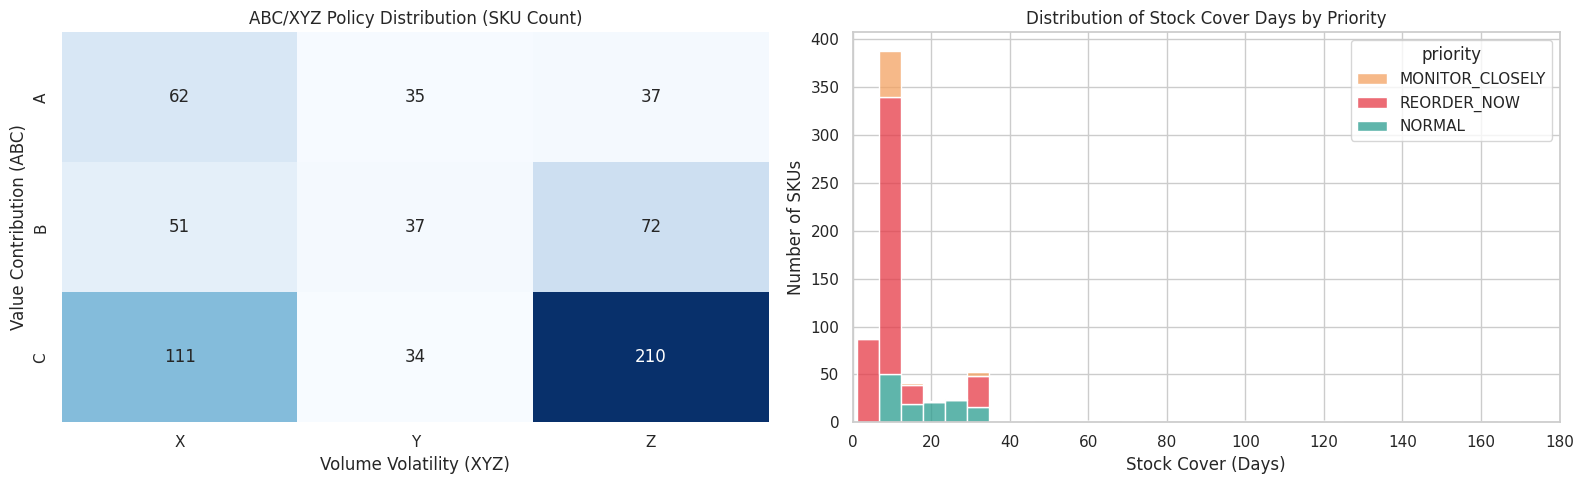

Most Critical Reorder Candidates:


,product_id,policy_code,current_stock,rop,eoq,reorder_qty,stock_cover_days,priority
90,P0499,AY,1461,2300.478928,7138.103757,7139,6.342981,REORDER_NOW
19,P0364,AY,2647,3644.292427,6548.620283,6549,7.964895,REORDER_NOW
87,P0590,AX,1003,1209.539256,5955.698070,5956,6.689640,REORDER_NOW
83,P0296,AX,1336,1728.869585,5725.814396,5726,6.872428,REORDER_NOW
186,P0114,BZ,999,1150.202079,4752.059628,4753,10.193878,REORDER_NOW
10,P0131,AX,2040,2255.629058,4293.565238,4294,7.059638,REORDER_NOW
15,P0333,AX,1151,1440.050206,3486.549748,3487,6.609877,REORDER_NOW
628,P0119,CZ,7,8.883998,3152.159753,3153,10.000000,REORDER_NOW
149,P0311,BY,432,597.642378,3055.800495,3056,7.035831,REORDER_NOW
68,P0548,AX,783,844.487446,2921.668913,2922,7.658950,REORDER_NOW


In [18]:
# 5. Visualizing Inventory Health and Policy Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

# 1. Policy Distribution Matrix (Heatmap)
plt.subplot(1, 2, 1)
matrix_data = final_df.groupby(['abc_class', 'xyz_class']).size().reset_index(name='count')
pivot_matrix = matrix_data.pivot(index='abc_class', columns='xyz_class', values='count').fillna(0)
sns.heatmap(pivot_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('ABC/XYZ Policy Distribution (SKU Count)')
plt.xlabel('Volume Volatility (XYZ)')
plt.ylabel('Value Contribution (ABC)')

# 2. Stock Cover & Reorder Priority Distribution
plt.subplot(1, 2, 2)
# Filter unrealistic outliers for clarity
plot_df = final_df[final_df['stock_cover_days'] < 180].copy()
sns.histplot(
    data=plot_df,
    x='stock_cover_days',
    hue='priority',
    multiple='stack',
    palette={'REORDER_NOW': '#e63946', 'MONITOR_CLOSELY': '#f4a261', 'NORMAL': '#2a9d8f'},
    bins=30
)
plt.title('Distribution of Stock Cover Days by Priority')
plt.xlabel('Stock Cover (Days)')
plt.ylabel('Number of SKUs')
plt.xlim(0, 180)

plt.tight_layout()
plt.show()

# Display Top 10 Most Critical Reorder Candidates
print('Most Critical Reorder Candidates:')
display(
    final_df[['product_id', 'policy_code', 'current_stock', 'rop', 'eoq', 'reorder_qty', 'stock_cover_days', 'priority']]
    .sort_values(['priority', 'reorder_qty'], ascending=[False, False])
    .head(10)
)

### Additional Inventory Exploratory Analysis

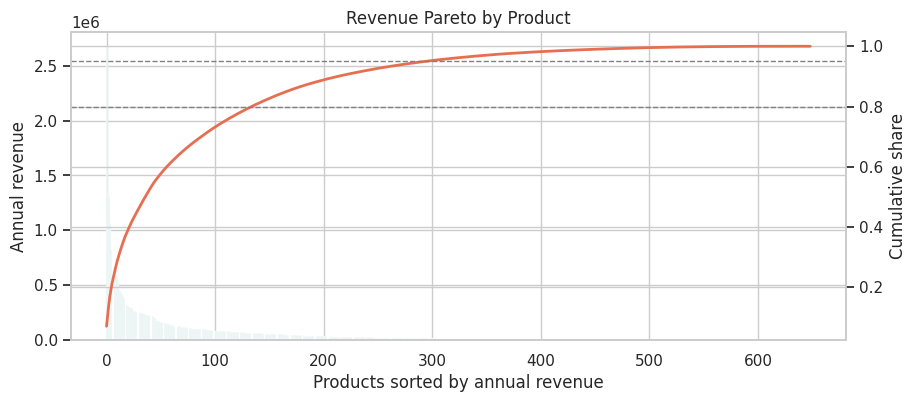

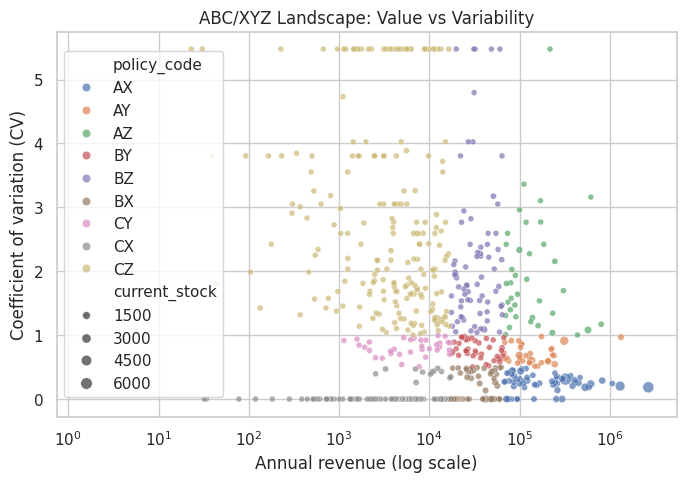

Slow mover SKU count: 87


,product_id,daily_demand,current_stock,stock_cover_days
6,P0316,0.065200,1,15.337423
42,P0438,0.033333,45,1350.000000
138,P0474,0.066667,1,15.000000
145,P0397,0.033333,1,30.000000
170,P0398,0.033333,1,30.000000
211,P0148,0.033333,12,360.000000
214,P0669,0.033333,1,30.000000
258,P0233,0.066667,1,15.000000
272,P0571,0.033333,1,30.000000
299,P0265,0.033333,20,600.000000


In [19]:
# Revenue Pareto (ABC intuition)
pareto = (
    final_df[['product_id', 'annual_revenue']]
    .sort_values('annual_revenue', ascending=False)
    .reset_index(drop=True)
)
pareto['cum_share'] = pareto['annual_revenue'].cumsum() / max(pareto['annual_revenue'].sum(), 1e-9)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(pareto.index, pareto['annual_revenue'], color='#2a9d8f', alpha=0.8)
ax1.set_title('Revenue Pareto by Product')
ax1.set_xlabel('Products sorted by annual revenue')
ax1.set_ylabel('Annual revenue')

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['cum_share'], color='#e76f51', linewidth=2)
ax2.axhline(0.80, linestyle='--', color='gray', linewidth=1)
ax2.axhline(0.95, linestyle='--', color='gray', linewidth=1)
ax2.set_ylabel('Cumulative share')
plt.show()

# ABC/XYZ scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=final_df,
    x='annual_revenue',
    y='cv',
    hue='policy_code',
    size='current_stock',
    alpha=0.7
)
plt.xscale('log')
plt.title('ABC/XYZ Landscape: Value vs Variability')
plt.xlabel('Annual revenue (log scale)')
plt.ylabel('Coefficient of variation (CV)')
plt.show()

# Dead stock / slow movers
slow_movers = final_df[final_df['daily_demand'] <= final_df['daily_demand'].median() / 10.0]
print('Slow mover SKU count:', len(slow_movers))
display(slow_movers[['product_id', 'daily_demand', 'current_stock', 'stock_cover_days']].head(20))

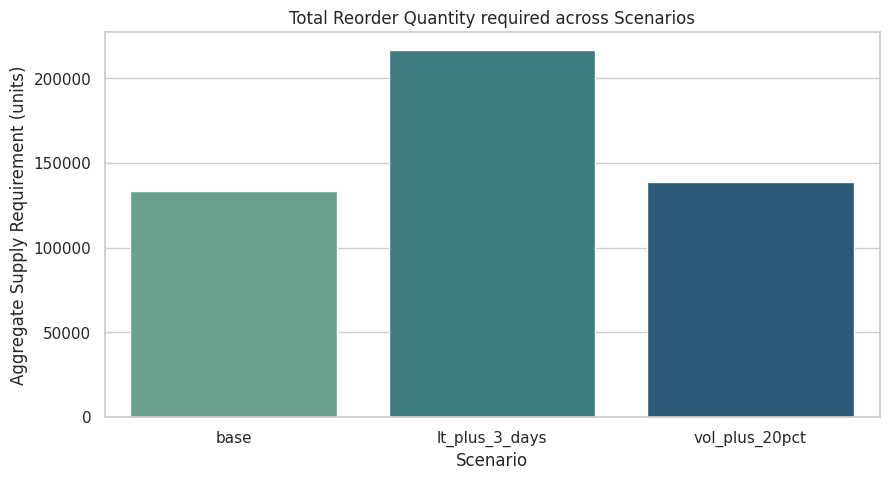

Reorder quantity sensitivity by Class:


,ABC Class,reorder_qty__base,reorder_qty__lt_plus_3_days,reorder_qty__vol_plus_20pct
0,A,71599,131918,72180
1,B,35379,52458,38203
2,C,26702,32222,28270


In [20]:
# 6. Sensitivity analysis: lead-time and variability multipliers
def scenario_view(base: pd.DataFrame, lead_time_days: int, demand_std_mult: float) -> pd.DataFrame:
    tmp = base.copy()
    tmp['safety_stock_scn'] = cfg.service_z * (tmp['demand_std_daily'] * demand_std_mult) * np.sqrt(lead_time_days)
    tmp['rop_scn'] = (tmp['daily_demand'] * lead_time_days) + tmp['safety_stock_scn']
    tmp['qty_to_rop_scn'] = (tmp['rop_scn'] - tmp['current_stock']).clip(lower=0)

    # Match the same reorder policy used in compute_rop_eoq.
    tmp['reorder_qty_scn'] = np.where(
        tmp['current_stock'] < tmp['rop_scn'],
        np.ceil(np.maximum(tmp['qty_to_rop_scn'], tmp['eoq'])),
        0.0,
    ).astype(int)
    return tmp[['product_id', 'policy_code', 'reorder_qty_scn']]

base_cols = final_df[['product_id', 'policy_code', 'daily_demand', 'demand_std_daily', 'current_stock', 'eoq']].copy()
scenarios = [
    ('base', cfg.lead_time_days, 1.0),
    ('lt_plus_3_days', cfg.lead_time_days + 3, 1.0),
    ('vol_plus_20pct', cfg.lead_time_days, 1.2),
]

scenario_tables = []
scenario_totals = []
for name, lt, mult in scenarios:
    t = scenario_view(base_cols, lt, mult).rename(columns={'reorder_qty_scn': f'reorder_qty__{name}'})
    scenario_tables.append(t)
    scenario_totals.append({'Scenario': name, 'Total Reorder Qty': t[f'reorder_qty__{name}'].sum()})

sensitivity_df = scenario_tables[0]
for t in scenario_tables[1:]:
    sensitivity_df = sensitivity_df.merge(t, on=['product_id', 'policy_code'], how='left')

# Grouped bar chart comparing scenarios
totals_df = pd.DataFrame(scenario_totals)
plt.figure(figsize=(10, 5))
sns.barplot(data=totals_df, x='Scenario', y='Total Reorder Qty', hue='Scenario', palette='crest', legend=False)
plt.title('Total Reorder Quantity required across Scenarios')
plt.ylabel('Aggregate Supply Requirement (units)')
plt.show()

# Aggregated by ABC Class
def agg_scenario(scenario_name):
    return sensitivity_df.groupby(sensitivity_df['policy_code'].str[0])[f'reorder_qty__{scenario_name}'].sum().reset_index()

class_comparison = agg_scenario('base')
class_comparison = class_comparison.merge(agg_scenario('lt_plus_3_days'), on='policy_code')
class_comparison = class_comparison.merge(agg_scenario('vol_plus_20pct'), on='policy_code')
class_comparison.rename(columns={'policy_code': 'ABC Class'}, inplace=True)

print('Reorder quantity sensitivity by Class:')
display(class_comparison)

## 7. Inspect Output and Persist Results

In [21]:
agent_ready_cols = [
    'product_id', 'policy_code', 'abc_class', 'xyz_class',
    'daily_demand', 'demand_std_daily', 'cv',
    'current_stock', 'rop', 'eoq', 'reorder_qty',
    'priority', 'priority_rank', 'overstock_flag', 'stock_cover_days',
    'annual_revenue', 'reasoning'
]

existing_cols = [c for c in agent_ready_cols if c in final_df.columns]
recommendations_df = final_df[existing_cols].sort_values(['priority_rank', 'reorder_qty'], ascending=[True, False])

output_csv = Path(cfg.output_dir) / 'inventory_recommendations_abc_xyz.csv'
sensitivity_csv = Path(cfg.output_dir) / 'inventory_sensitivity.csv'
summary_csv = Path(cfg.output_dir) / 'inventory_policy_summary.csv'

recommendations_df.to_csv(output_csv, index=False)
sensitivity_df.to_csv(sensitivity_csv, index=False)

policy_summary = recommendations_df.groupby('policy_code', as_index=False).agg(
    sku_count=('product_id', 'count'),
    avg_reorder_qty=('reorder_qty', 'mean')
)
policy_summary.to_csv(summary_csv, index=False)

display(policy_summary.sort_values('sku_count', ascending=False))
print('Saved:', output_csv)
print('Saved:', sensitivity_csv)
print('Saved:', summary_csv)

,policy_code,sku_count,avg_reorder_qty
8,CZ,210,74.595238
6,CX,111,45.027027
5,BZ,72,190.208333
0,AX,62,543.000000
3,BX,51,147.627451
2,AZ,37,295.405405
4,BY,37,382.567568
1,AY,35,771.514286
7,CY,34,177.617647


Saved: artifacts/inventory_analysis/inventory_recommendations_abc_xyz.csv
Saved: artifacts/inventory_analysis/inventory_sensitivity.csv
Saved: artifacts/inventory_analysis/inventory_policy_summary.csv
